# Recommendation Systems - MovieLens 100K

This project combines Collaborative Filtering (1) and Content-Based Filtering (2), making it a hybrid model. 

1) Collaborative Filtering - It predicts what a user will like based on the patterns of other **similar users**.

2) Content-Based Filtering - It recommends items based on the **characteristics of the items themselves** and the user's profile.

---
*Modular version: heavy logic now lives in `src/` (`preprocessing.py`, `content_based.py`, `collaborative.py`, `hybrid.py`). This notebook only orchestrates and visualizes.*

In [5]:
import os 
os.chdir("..") 
print(os.getcwd())

c:\Users\gonca\Desktop\Projetos\HybridRecommendationSystem


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.preprocessing import clean_data, multi_holdout_split
from src.content_based import build_content_model, recommend_content
from src.collaborative import build_collaborative_model
from src.hybrid import (
    build_id_index,
    hybrid_recommend,
    recommend_for_user,
    precision_recall_at_k,
    evaluate_alphas,
)

### Dataset Load & Preprocessing

`clean_data()` loads the raw CSVs, merges movies+links+tags, fetches TMDB descriptions (cached to `data/movies_with_descriptions.csv` after the first run), and builds the `combined_text` field used for embeddings.

In [7]:
ratings, movies = clean_data(data_dir="data", fetch_descriptions=True)

print(f"{len(ratings):,} ratings | {len(movies):,} movies")
movies.head()

'data\movies_with_descriptions.csv' already exists — loading cached descriptions.
100,836 ratings | 9,742 movies


,movieId,title,genres,imdbId,tmdbId,genres_clean,description,userId,tag,timestamp,tags,year,combined_text
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,114709,862.0,AdventureAnimationChildrenComedyFantasy,"Led by Woody, Andy's toys live happily in his ...",336.0,pixar,1.139046e+09,pixar fun,1995,"Led by Woody, Andy's toys live happily in his ..."
1,2,Jumanji (1995),Adventure|Children|Fantasy,113497,8844.0,AdventureChildrenFantasy,When siblings Judy and Peter discover an encha...,62.0,fantasy,1.528844e+09,fantasy magic board game Robin Williams game,1995,When siblings Judy and Peter discover an encha...
2,3,Grumpier Old Men (1995),Comedy|Romance,113228,15602.0,ComedyRomance,A family wedding reignites the ancient feud be...,289.0,moldy,1.143425e+09,moldy old,1995,A family wedding reignites the ancient feud be...
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,114885,31357.0,ComedyDramaRomance,"Cheated on, mistreated and stepped on, the wom...",NaN,NaN,NaN,,1995,"Cheated on, mistreated and stepped on, the wom..."
4,5,Father of the Bride Part II (1995),Comedy,113041,11862.0,Comedy,Just when George Banks has recovered from his ...,474.0,pregnancy,1.137374e+09,pregnancy remake,1995,Just when George Banks has recovered from his ...


## Content-Based Filtering

`build_content_model()` encodes each movie's `combined_text` (description + genres + year + tags + title) with a SentenceTransformer, then computes cosine similarity between all movies. Embeddings are cached to `models/movie_embeddings.pkl` — delete that file (or pass `recompute=True`) to force a re-encode.

In [8]:
embeddings, cb_similarity = build_content_model(
    movies,
    embeddings_path="models/movie_embeddings.pkl",
)
print(cb_similarity.shape)

(9742, 9742)


### Recommendation function (content-based only)

In [9]:
recommend_content("Toy Story (1995)", movies, cb_similarity, top_n=10)

Title 'Toy Story (1995)' not found.


c:\Users\gonca\Desktop\Projetos\HybridRecommendationSystem\src\content_based.py:145: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  matches = movies_df[movies_df["title"].str.contains(title, case=False, na=False)]


,title,description


## Collaborative Filtering

We hold out a few "liked" movies per user as a test set (`multi_holdout_split`), build a user x movie ratings matrix from the training set, mean-center it per user, and compute item-item cosine similarity (`build_collaborative_model`).

In [10]:
ratings_train, ratings_test = multi_holdout_split(ratings)

item_similarity_cf = build_collaborative_model(ratings_train)
id_to_index = build_id_index(movies)

item_similarity_cf.shape

(9705, 9705)

**Hybrid function:** `hybrid_score = alpha * CB + (1 - alpha) * CF`
- alpha - weight given to Content-Based (1 - alpha goes to Collaborative Filtering)

In [11]:
hybrid_recommend("Matrix", movies, cb_similarity, item_similarity_cf, id_to_index, top_n=5, alpha=0.7)

,title,genres,description
2226,Fight Club (1999),Action|Crime|Drama|Thriller,A ticking-time-bomb insomniac and a slippery s...
5669,"Animatrix, The (2003)",Action|Animation|Drama|Sci-Fi,Straight from the creators of the groundbreaki...
4351,"Matrix Reloaded, The (2003)",Action|Adventure|Sci-Fi|Thriller|IMAX,The Resistance builds in numbers as humans are...
6433,300 (2007),Action|Fantasy|War|IMAX,A story very loosely based the 480 B.C. Battle...
1402,Pi (1998),Drama|Sci-Fi|Thriller,A mathematical genius discovers a link between...


### Evaluate the impact of alpha (single-title view)

In [12]:
# alpha = 0.3 CF dominant
# alpha = 0.5 CF and CB balanced
# alpha = 0.7 CB dominant

for alpha in [0.3, 0.5, 0.7, 0.9]:
    print(f"\nAlpha = {alpha}")
    print(hybrid_recommend("Matrix", movies, cb_similarity, item_similarity_cf, id_to_index, top_n=5, alpha=alpha)[["title", "genres"]])


Alpha = 0.3
                                                  title  \
2226                                  Fight Club (1999)   
1503                         Saving Private Ryan (1998)   
898   Star Wars: Episode V - The Empire Strikes Back...   
1243                                     Gattaca (1997)   
257                                 Pulp Fiction (1994)   

                           genres  
2226  Action|Crime|Drama|Thriller  
1503             Action|Drama|War  
898       Action|Adventure|Sci-Fi  
1243        Drama|Sci-Fi|Thriller  
257   Comedy|Crime|Drama|Thriller  

Alpha = 0.5
                                           title                       genres
2226                           Fight Club (1999)  Action|Crime|Drama|Thriller
1402                                   Pi (1998)        Drama|Sci-Fi|Thriller
596   Ghost in the Shell (Kôkaku kidôtai) (1995)             Animation|Sci-Fi
6433                                  300 (2007)      Action|Fantasy|War|IMAX
1503         

### Limitations: cold start
- **New user (no ratings):** CF has no signal at all — recommendations fall back entirely on CB (set alpha closer to 1.0 for these users).
- **New movie (no ratings yet):** CF has no signal for that movie either, but CB can still recommend it based on its description/genres/tags.

- **Precision@10** = average number of relevant items recommended / 10, per user
- **Recall@10** = average number of relevant items recommended / number of relevant items held out, per user

In [13]:
results_precision, results_recall = evaluate_alphas(
    ratings_test, ratings_train, movies, cb_similarity, item_similarity_cf, id_to_index,
    alphas=[0.0, 0.3, 0.5, 0.7, 0.9, 1.0], k=10,
)

alpha=0.0: Precision@10 = 0.0263, Recall@10 = 0.0877
alpha=0.3: Precision@10 = 0.0235, Recall@10 = 0.0784
alpha=0.5: Precision@10 = 0.0164, Recall@10 = 0.0548
alpha=0.7: Precision@10 = 0.0102, Recall@10 = 0.0340
alpha=0.9: Precision@10 = 0.0044, Recall@10 = 0.0148
alpha=1.0: Precision@10 = 0.0031, Recall@10 = 0.0104


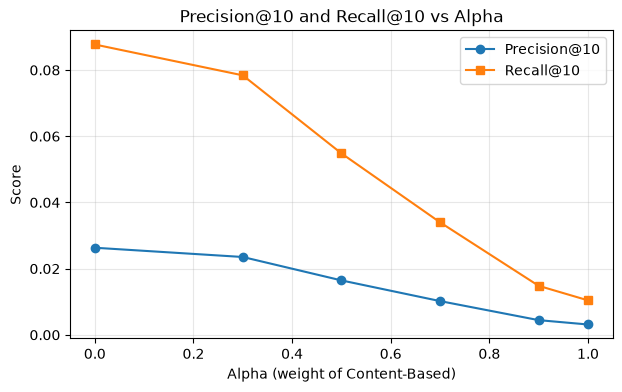

In [14]:
alphas = list(results_precision.keys())
precisions = list(results_precision.values())
recalls = list(results_recall.values())

plt.figure(figsize=(7, 4))
plt.plot(alphas, precisions, marker='o', label='Precision@10')
plt.plot(alphas, recalls, marker='s', label='Recall@10')
plt.xlabel('Alpha (weight of Content-Based)')
plt.ylabel('Score')
plt.title('Precision@10 and Recall@10 vs Alpha')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Interpretation: Precision@10 and Recall@10 vs Alpha 
- Just like Recall@10 on its own, Precision@10 confirms the same pattern: both metrics peak at **alpha = 0.3** (CF dominant) and consistently decrease as the weight of content-based increases. The fact that two different metrics agree reinforces the previous conclusion — it's not an isolated coincidence of one metric, but a consistent signal that CF captures the individual user's taste better than CB thematic similarity, at least in this dataset and for this top-K ranking task.
- The absolute values of the two metrics aren't directly comparable: Precision@10 always divides by the fixed list size (10), while Recall@10 divides by the number of relevant items hidden per user (3, in this split). That's why Recall@10 tends to be structurally higher than Precision@10 for the same number of hits — the difference in magnitude between the curves doesn't say anything about model quality, it just reflects the different denominators.
- As before, this doesn't invalidate the CB component — it's still essential for cold-start of new movies and for thematic diversity — but it confirms that, to maximize direct hits in recommendations (Precision and Recall), a lower alpha (giving more weight to CF) is the most defensible choice on this dataset.